In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

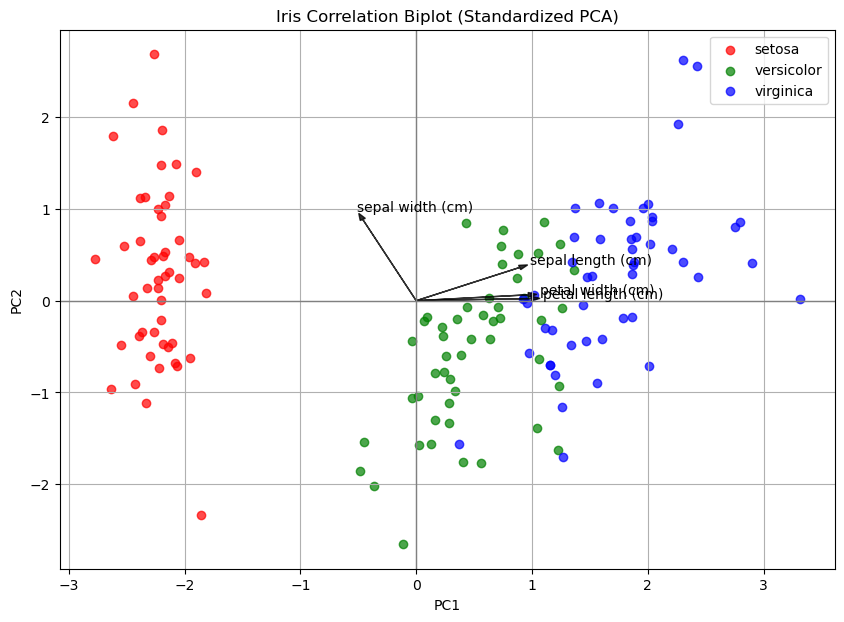

PC1 方差占比: 0.7296244541329989
PC2 方差占比: 0.22850761786701754
累计解释方差: 0.9581320720000165


In [ ]:
#载入数据
iris = datasets.load_iris()
X = iris.data
y = iris.target
features = iris.feature_names
target_names = iris.target_names

#标准化
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

#PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

#correlation biplot loading
eigenvalues = pca.explained_variance_
loadings = pca.components_.T * np.sqrt(eigenvalues)


#画图
plt.figure(figsize=(10, 7))

#scores（样本点）
colors = ['red', 'green', 'blue']
for i, label in enumerate(np.unique(y)):
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label=target_names[label],
        alpha=0.7,
        color=colors[i]
    )

#variables（箭头）
for i, feature in enumerate(features):
    plt.arrow(
        0, 0,
        loadings[i, 0],
        loadings[i, 1],
        color='black',
        alpha=0.8,
        head_width=0.05
    )
    plt.text(
        loadings[i, 0] * 1.1,
        loadings[i, 1] * 1.1,
        feature,
        color='black'
    )

#美化
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Iris Correlation Biplot (Standardized PCA)")
plt.legend()
plt.grid()
plt.show()

#方差解释比例
explained_var = pca.explained_variance_ratio_

print("PC1 方差占比:", explained_var[0])
print("PC2 方差占比:", explained_var[1])
print("累计解释方差:", explained_var[0] + explained_var[1])

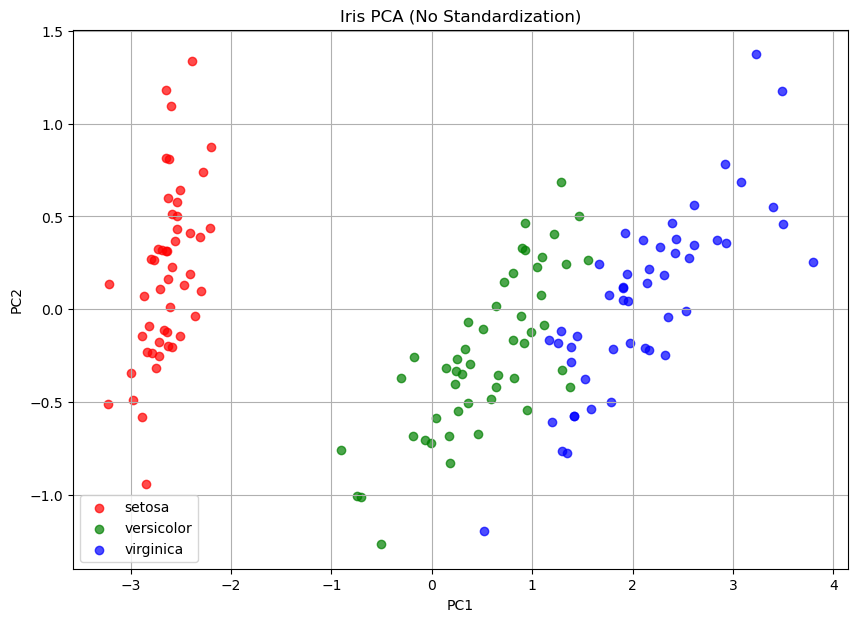

In [3]:
#非标准化PCA
pca_raw = PCA(n_components=2)
X_pca_raw = pca_raw.fit_transform(X) # 不做标准化

eigenvalues_raw = pca_raw.explained_variance_
loadings_raw = pca_raw.components_.T * np.sqrt(eigenvalues_raw)

plt.figure(figsize=(10, 7))

for i, label in enumerate(np.unique(y)):
    plt.scatter(
    X_pca_raw[y == label, 0],
    X_pca_raw[y == label, 1],
    label=target_names[label],
    alpha=0.7,
    color=colors[i]
    )

plt.title("Iris PCA (No Standardization)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

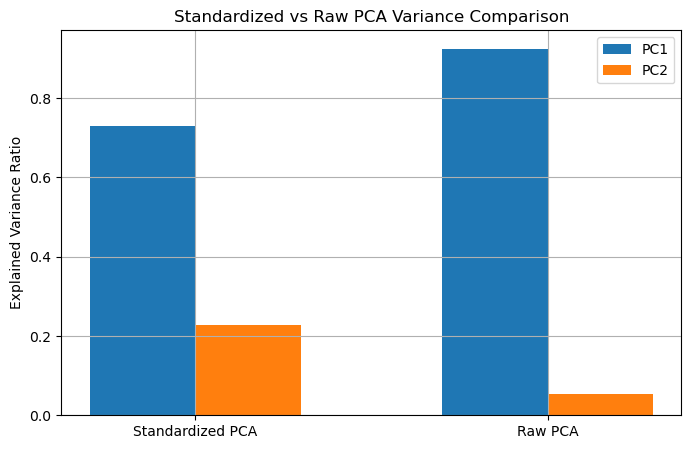

In [4]:
#标准化与非标准化对比
plt.figure(figsize=(8, 5))

labels = ["Standardized PCA", "Raw PCA"]

pc1_var = [pca.explained_variance_ratio_[0],
pca_raw.explained_variance_ratio_[0]]

pc2_var = [pca.explained_variance_ratio_[1],
pca_raw.explained_variance_ratio_[1]]

x = np.arange(len(labels))

plt.bar(x - 0.15, pc1_var, width=0.3, label="PC1")
plt.bar(x + 0.15, pc2_var, width=0.3, label="PC2")

plt.xticks(x, labels)
plt.ylabel("Explained Variance Ratio")
plt.title("Standardized vs Raw PCA Variance Comparison")
plt.legend()
plt.grid()
plt.show()

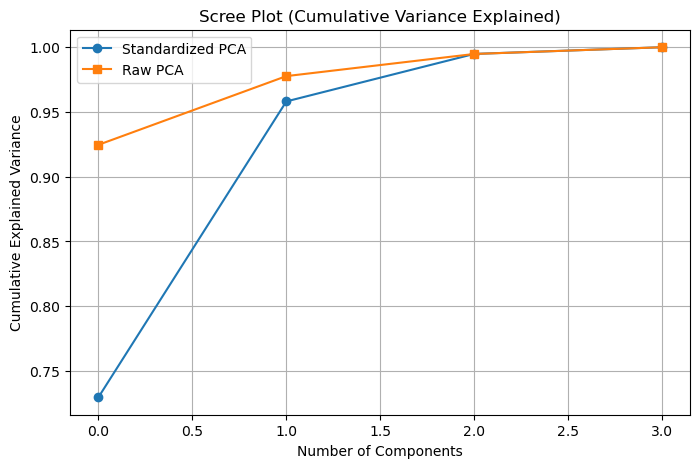

In [5]:
#累计贡献率曲线
pca_full_std = PCA().fit(X_std)
pca_full_raw = PCA().fit(X)

plt.figure(figsize=(8, 5))

plt.plot(np.cumsum(pca_full_std.explained_variance_ratio_),
marker='o', label="Standardized PCA")

plt.plot(np.cumsum(pca_full_raw.explained_variance_ratio_),
marker='s', label="Raw PCA")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot (Cumulative Variance Explained)")
plt.legend()
plt.grid()
plt.show()